# Body Performance Analysis

This notebook analyzes the Body Performance dataset through two machine learning tasks:

- classification to predict the performance class
- regression to predict broad jump distance

The workflow includes data understanding, cleaning, exploratory data analysis, feature engineering, model training, and final evaluation.

In [1]:
# data handling
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# display settings — makes outputs easier to read
pd.set_option('display.max_columns', None)
pd.set_option("display.float_format", "{:.2f}".format)

# load the dataset
df = pd.read_csv("bodyPerformance.csv")


## First look at the data

The first step is to inspect the dataset structure directly by checking its size, columns, and a small sample of rows. This provides an initial understanding of what the dataset contains before any cleaning or analysis is performed.

In [2]:
# quick look
print("Dataset shape:", df.shape)
print("\ncolumn names:")
print(df.columns.tolist())

print("\nfirst 5 rows:")
display(df.head())

Dataset shape: (13393, 12)

column names:
['age', 'gender', 'height_cm', 'weight_kg', 'body fat_%', 'diastolic', 'systolic', 'gripForce', 'sit and bend forward_cm', 'sit-ups counts', 'broad jump_cm', 'class']

first 5 rows:


,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.00,M,172.30,75.24,21.30,80.00,130.00,54.90,18.40,60.00,217.00,C
1,25.00,M,165.00,55.80,15.70,77.00,126.00,36.40,16.30,53.00,229.00,A
2,31.00,M,179.60,78.00,20.10,92.00,152.00,44.80,12.00,49.00,181.00,C
3,32.00,M,174.50,71.10,18.40,76.00,147.00,41.40,15.20,53.00,219.00,B
4,28.00,M,173.80,67.70,17.10,70.00,127.00,43.50,27.10,45.00,217.00,B


Each row is one participant. The columns cover the basics you'd expect in a fitness assessment — age, height, weight, body fat, blood pressure readings, grip strength, flexibility, sit-up count, and broad jump distance. The `class` column is our classification target.


## Column Understanding

Each column is reviewed below in terms of its meaning, expected type, and a simple validation rule. This step is important because the project handbook requires column-level understanding before further preprocessing and modeling.

| Column                  | Meaning                  | Type        | Example constraint                   |
| ----------------------- | ------------------------ | ----------- | ------------------------------------ |
| age                     | participant age          | numeric     | positive                             |
| gender                  | participant gender       | categorical | limited set of categories            |
| height_cm               | height in cm             | numeric     | positive                             |
| weight_kg               | weight in kg             | numeric     | positive                             |
| body fat_%              | body fat percentage      | numeric     | non-negative                         |
| diastolic               | diastolic blood pressure | numeric     | realistic physiological range        |
| systolic                | systolic blood pressure  | numeric     | systolic > diastolic in normal cases |
| gripForce               | grip strength            | numeric     | non-negative                         |
| sit and bend forward_cm | flexibility test         | numeric     | can be negative                      |
| sit-ups counts          | muscular endurance count | numeric     | non-negative integer-like            |
| broad jump_cm           | jump distance            | numeric     | non-negative                         |
| class                   | performance category     | categorical | ordered class labels                 |


## Checking the data types

Checking data types is an important step because incorrect formats can affect later analysis, preprocessing, and modeling.


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13393 entries, 0 to 13392
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      13393 non-null  float64
 1   gender                   13393 non-null  object 
 2   height_cm                13393 non-null  float64
 3   weight_kg                13393 non-null  float64
 4   body fat_%               13393 non-null  float64
 5   diastolic                13393 non-null  float64
 6   systolic                 13393 non-null  float64
 7   gripForce                13393 non-null  float64
 8   sit and bend forward_cm  13393 non-null  float64
 9   sit-ups counts           13393 non-null  float64
 10  broad jump_cm            13393 non-null  float64
 11  class                    13393 non-null  object 
dtypes: float64(10), object(2)
memory usage: 1.2+ MB


The data types appear correct. Numeric variables are stored as numeric values, while `gender` and `class` are categorical fields stored as objects. No correction is needed at this stage.

## Descriptive statistics

Descriptive statistics provide an initial summary of the numeric variables, including their central tendency, spread, and overall range. This helps identify variables that may require closer inspection in later validity and outlier checks.

In [4]:
display(df.describe())

,age,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm
count,13393.00,13393.00,13393.00,13393.00,13393.00,13393.00,13393.00,13393.00,13393.00,13393.00
mean,36.78,168.56,67.45,23.24,78.80,130.23,36.96,15.21,39.77,190.13
std,13.63,8.43,11.95,7.26,10.74,14.71,10.62,8.46,14.28,39.87
min,21.00,125.00,26.30,3.00,0.00,0.00,0.00,-25.00,0.00,0.00
25%,25.00,162.40,58.20,18.00,71.00,120.00,27.50,10.90,30.00,162.00
50%,32.00,169.20,67.40,22.80,79.00,130.00,37.90,16.20,41.00,193.00
75%,48.00,174.80,75.30,28.00,86.00,141.00,45.20,20.70,50.00,221.00
max,64.00,193.80,138.10,78.40,156.20,201.00,70.50,213.00,80.00,303.00


The descriptive statistics suggest that most variables fall within reasonable ranges, although some minimum and maximum values appear unusual. These cases are examined more carefully in the validity and outlier analysis sections.

## Checking for missing values

Missing values are the first thing to deal with before any modeling. They can silently distort statistics, break pipelines, and introduce bias if handled carelessly. We check every column.


In [5]:
missing_summary = pd.DataFrame({
    'missing_count' : df.isna().sum(),
    'missing_percentage' : (df.isna().mean() * 100).round(2)
})

display(missing_summary)

,missing_count,missing_percentage
age,0,0.00
gender,0,0.00
height_cm,0,0.00
weight_kg,0,0.00
body fat_%,0,0.00
diastolic,0,0.00
systolic,0,0.00
gripForce,0,0.00
sit and bend forward_cm,0,0.00
sit-ups counts,0,0.00


No missing values were found in any column. Since the dataset is complete, no imputation strategy is required.

## Checking for duplicates

Duplicate rows should be identified before modeling because repeated records can bias summary statistics and artificially improve evaluation results.

In [6]:
duplicate_count = df.duplicated().sum()
duplicate_count

if duplicate_count > 0:
  display(df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist()))



,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
8965,27.00,F,157.00,49.10,30.70,70.00,86.00,27.70,19.70,51.00,167.00,A
12473,27.00,F,157.00,49.10,30.70,70.00,86.00,27.70,19.70,51.00,167.00,A


One exact duplicate row was detected and removed. This keeps the dataset cleaner and avoids repeated observations during training and evaluation.

In [7]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

## Validity checks

Some records may contain values that are not missing but are still invalid or unrealistic. Logical validity rules are therefore applied to detect records with impossible measurements.

In [8]:
validity_summary = pd.DataFrame({
     'issue' : [
        'age <= 0',
        'height_cm <= 0',
        'weight_kg <= 0',
        'body fat_% < 0 or > 100',
        'diastolic <= 0',
        'systolic <= 0',
        'gripForce <= 0',
        'sit-ups counts < 0',
        'broad jump_cm <= 0'
 ],
     'invalid_count': [
        (df['age'] <= 0).sum(),
        (df['height_cm'] <= 0).sum(),
        (df['weight_kg'] <= 0).sum(),
        ((df['body fat_%'] < 0) |
 (df['body fat_%'] > 100)).sum(),
        (df['diastolic'] <= 0).sum(),
        (df['systolic'] <= 0).sum(),
        (df['gripForce'] <= 0).sum(),
        (df['sit-ups counts'] < 0).sum(),
        (df['broad jump_cm'] <= 0).sum()
    ]
})

display(validity_summary)

,issue,invalid_count
0,age <= 0,0
1,height_cm <= 0,0
2,weight_kg <= 0,0
3,body fat_% < 0 or > 100,0
4,diastolic <= 0,1
5,systolic <= 0,1
6,gripForce <= 0,3
7,sit-ups counts < 0,0
8,broad jump_cm <= 0,10


In [9]:
invalid_rows = df[
    (df['diastolic'] <= 0) |
    (df['systolic'] <= 0) |
    (df['gripForce'] <= 0) |
    (df['broad jump_cm'] <= 0)
]

display(invalid_rows)

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
484,22.00,F,167.40,66.20,34.00,62.00,110.00,28.50,11.20,38.00,0.00,C
712,58.00,M,168.70,76.10,27.50,84.00,139.00,34.50,2.00,0.00,0.00,D
1919,59.00,F,162.90,61.00,32.60,82.00,123.00,29.70,19.50,0.00,0.00,D
4756,28.00,M,176.60,82.20,20.70,83.00,126.00,40.90,17.60,46.00,0.00,C
4900,60.00,F,162.20,67.30,41.80,47.00,131.00,22.10,19.50,0.00,0.00,D
7366,50.00,M,178.20,88.40,23.40,85.00,146.00,54.90,19.30,51.00,0.00,C
7721,56.00,F,156.00,51.10,28.40,73.00,113.00,20.70,23.00,23.00,0.00,C
7944,45.00,F,153.40,33.70,16.10,81.00,124.00,6.70,11.50,8.00,0.00,D
7954,61.00,F,153.00,64.60,31.40,77.00,152.00,14.00,20.60,0.00,0.00,D
8562,22.00,F,160.40,52.30,34.20,79.00,111.00,0.00,15.20,45.00,165.00,D


A small handful of records had clearly invalid values — zeros where zero is physically impossible. Because these represent a tiny fraction of the dataset, removing them is safer and cleaner than trying to guess what the real values should have been.


In [10]:
suspicious_extremes = df[
    (df['sit and bend forward_cm'] > 100) |
    (df['body fat_%'] > 60)
]

display(suspicious_extremes)

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
735,21.00,M,177.60,74.50,78.40,69.00,122.00,44.90,26.10,59.00,235.00,A
2657,33.00,M,165.60,60.40,17.80,81.00,127.00,38.60,213.00,53.00,244.00,B
3355,45.00,M,164.40,64.40,24.30,96.00,142.00,38.50,185.00,44.00,223.00,A


## Where we stand after basic cleaning

After removing clearly invalid records, the remaining unusual values appear to be extreme but still potentially valid observations, so they are inspected carefully before any further decision is made.


In [11]:
# df at this point already has duplicates removed (handled above)
# Here we apply the invalid-row removal and produce df_clean_basic
df_raw = df.copy()

invalid_mask = (
    (df_raw['diastolic'] <= 0) |
    (df_raw['systolic'] <= 0) |
    (df_raw['gripForce'] <= 0) |
    (df_raw['broad jump_cm'] <= 0)
)

invalid_rows = df_raw.loc[invalid_mask].copy()
display(invalid_rows)

df_clean_basic = df_raw.loc[~invalid_mask].copy()
df_clean_basic.reset_index(drop=True, inplace=True)

print(f'Invalid rows removed: {invalid_rows.shape[0]}')
print(f'Shape after basic cleaning: {df_clean_basic.shape}')


,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
484,22.00,F,167.40,66.20,34.00,62.00,110.00,28.50,11.20,38.00,0.00,C
712,58.00,M,168.70,76.10,27.50,84.00,139.00,34.50,2.00,0.00,0.00,D
1919,59.00,F,162.90,61.00,32.60,82.00,123.00,29.70,19.50,0.00,0.00,D
4756,28.00,M,176.60,82.20,20.70,83.00,126.00,40.90,17.60,46.00,0.00,C
4900,60.00,F,162.20,67.30,41.80,47.00,131.00,22.10,19.50,0.00,0.00,D
7366,50.00,M,178.20,88.40,23.40,85.00,146.00,54.90,19.30,51.00,0.00,C
7721,56.00,F,156.00,51.10,28.40,73.00,113.00,20.70,23.00,23.00,0.00,C
7944,45.00,F,153.40,33.70,16.10,81.00,124.00,6.70,11.50,8.00,0.00,D
7954,61.00,F,153.00,64.60,31.40,77.00,152.00,14.00,20.60,0.00,0.00,D
8562,22.00,F,160.40,52.30,34.20,79.00,111.00,0.00,15.20,45.00,165.00,D


Invalid rows removed: 14
Shape after basic cleaning: (13378, 12)


In [12]:
# Flag highly suspicious extreme values for later outlier analysis
suspicious_mask = (
    (df_clean_basic['body fat_%'] > 60) |
    (df_clean_basic['sit and bend forward_cm'] > 100)
)

suspicious_rows = df_clean_basic.loc[suspicious_mask].copy()
display(suspicious_rows)

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
733,21.00,M,177.60,74.50,78.40,69.00,122.00,44.90,26.10,59.00,235.00,A
2654,33.00,M,165.60,60.40,17.80,81.00,127.00,38.60,213.00,53.00,244.00,B
3352,45.00,M,164.40,64.40,24.30,96.00,142.00,38.50,185.00,44.00,223.00,A


In [13]:
display(df_clean_basic.describe().T)
df_clean_basic.info()

,count,mean,std,min,25%,50%,75%,max
age,13378.00,36.77,13.62,21.00,25.00,32.00,48.00,64.00
height_cm,13378.00,168.56,8.43,125.00,162.40,169.20,174.80,193.80
weight_kg,13378.00,67.45,11.95,26.30,58.20,67.44,75.30,138.10
body fat_%,13378.00,23.23,7.25,3.00,18.00,22.80,28.00,78.40
diastolic,13378.00,78.80,10.72,6.00,71.00,79.00,86.00,156.20
systolic,13378.00,130.25,14.67,14.00,120.00,130.00,141.00,201.00
gripForce,13378.00,36.98,10.61,1.60,27.50,37.90,45.20,70.50
sit and bend forward_cm,13378.00,15.21,8.46,-25.00,10.90,16.20,20.77,213.00
sit-ups counts,13378.00,39.79,14.26,0.00,30.00,41.00,50.00,80.00
broad jump_cm,13378.00,190.27,39.54,20.00,162.00,193.00,221.00,303.00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13378 entries, 0 to 13377
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      13378 non-null  float64
 1   gender                   13378 non-null  object 
 2   height_cm                13378 non-null  float64
 3   weight_kg                13378 non-null  float64
 4   body fat_%               13378 non-null  float64
 5   diastolic                13378 non-null  float64
 6   systolic                 13378 non-null  float64
 7   gripForce                13378 non-null  float64
 8   sit and bend forward_cm  13378 non-null  float64
 9   sit-ups counts           13378 non-null  float64
 10  broad jump_cm            13378 non-null  float64
 11  class                    13378 non-null  object 
dtypes: float64(10), object(2)
memory usage: 1.2+ MB


## Categorical variable distributions

The categorical variables are examined to understand the participant composition and the class distribution before modeling.

In [14]:
# Frequency tables for categorical variables
gender_counts = df_clean_basic['gender'].value_counts()
gender_percent = df_clean_basic['gender'].value_counts(normalize=True) * 100

class_counts = df_clean_basic['class'].value_counts()
class_percent = df_clean_basic['class'].value_counts(normalize=True) * 100

print("Gender counts:")
display(pd.DataFrame({
    'count': gender_counts,
    'percentage': gender_percent.round(2)
}))

print("Class counts:")
display(pd.DataFrame({
    'count': class_counts,
    'percentage': class_percent.round(2)
}))

Gender counts:


,count,percentage
gender,,
M,8462,63.25
F,4916,36.75


Class counts:


,count,percentage
class,,
A,3347,25.02
B,3346,25.01
C,3344,25.00
D,3341,24.97


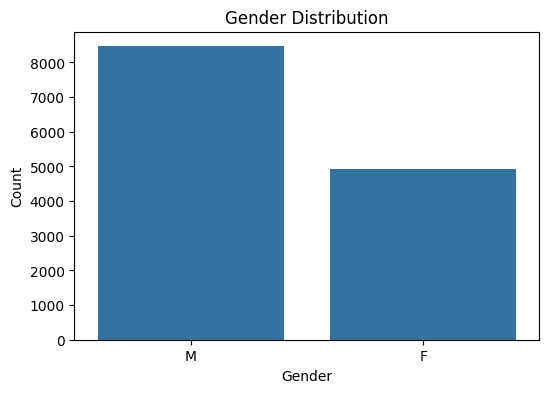

In [15]:

plt.figure(figsize=(6,4))
sns.countplot(data=df_clean_basic, x='gender')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

The dataset contains more male participants than female participants. This imbalance is important because some physical measurements may systematically differ by gender.

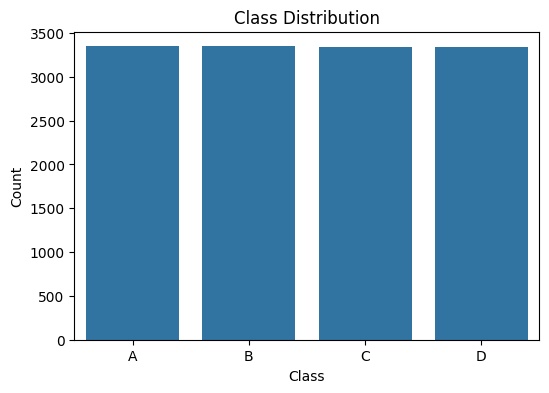

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_clean_basic, x='class', order=sorted(df_clean_basic['class'].unique()))
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

The four performance classes are distributed fairly evenly. This is helpful for classification because it reduces the risk of severe class imbalance.

## Distribution analysis

Histograms are used to examine the shape of numeric distributions, identify skewness, and detect unusual patterns or anomalies.

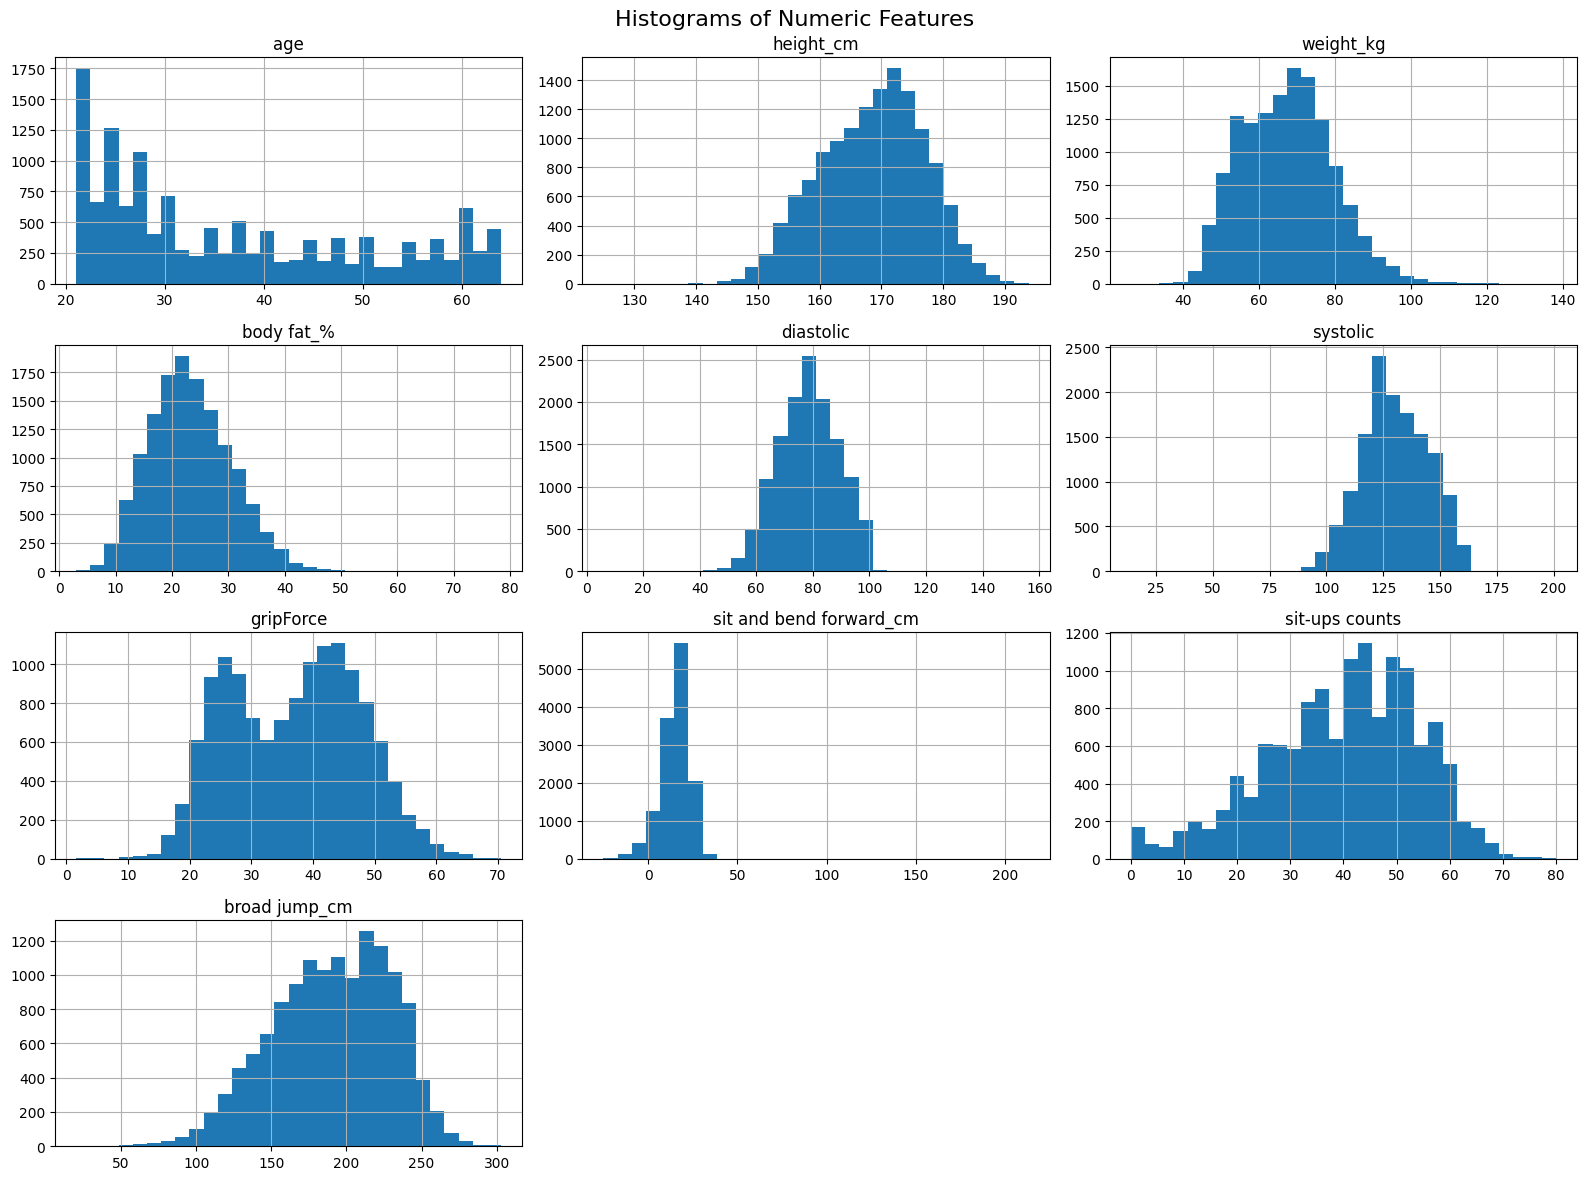

In [17]:
numeric_cols = df_clean_basic.select_dtypes(include='number').columns.tolist()

df_clean_basic[numeric_cols].hist(figsize=(16, 12), bins=30)
plt.suptitle('Histograms of Numeric Features', fontsize=16)
plt.tight_layout()
plt.show()


Most variables show reasonable distribution patterns. One notable case is `gripForce`, which appears bimodal. This likely reflects differences between participant groups rather than a data quality problem.

## Outlier inspection

Boxplots are used to detect extreme values and to distinguish between natural variation and observations that may represent data quality issues.

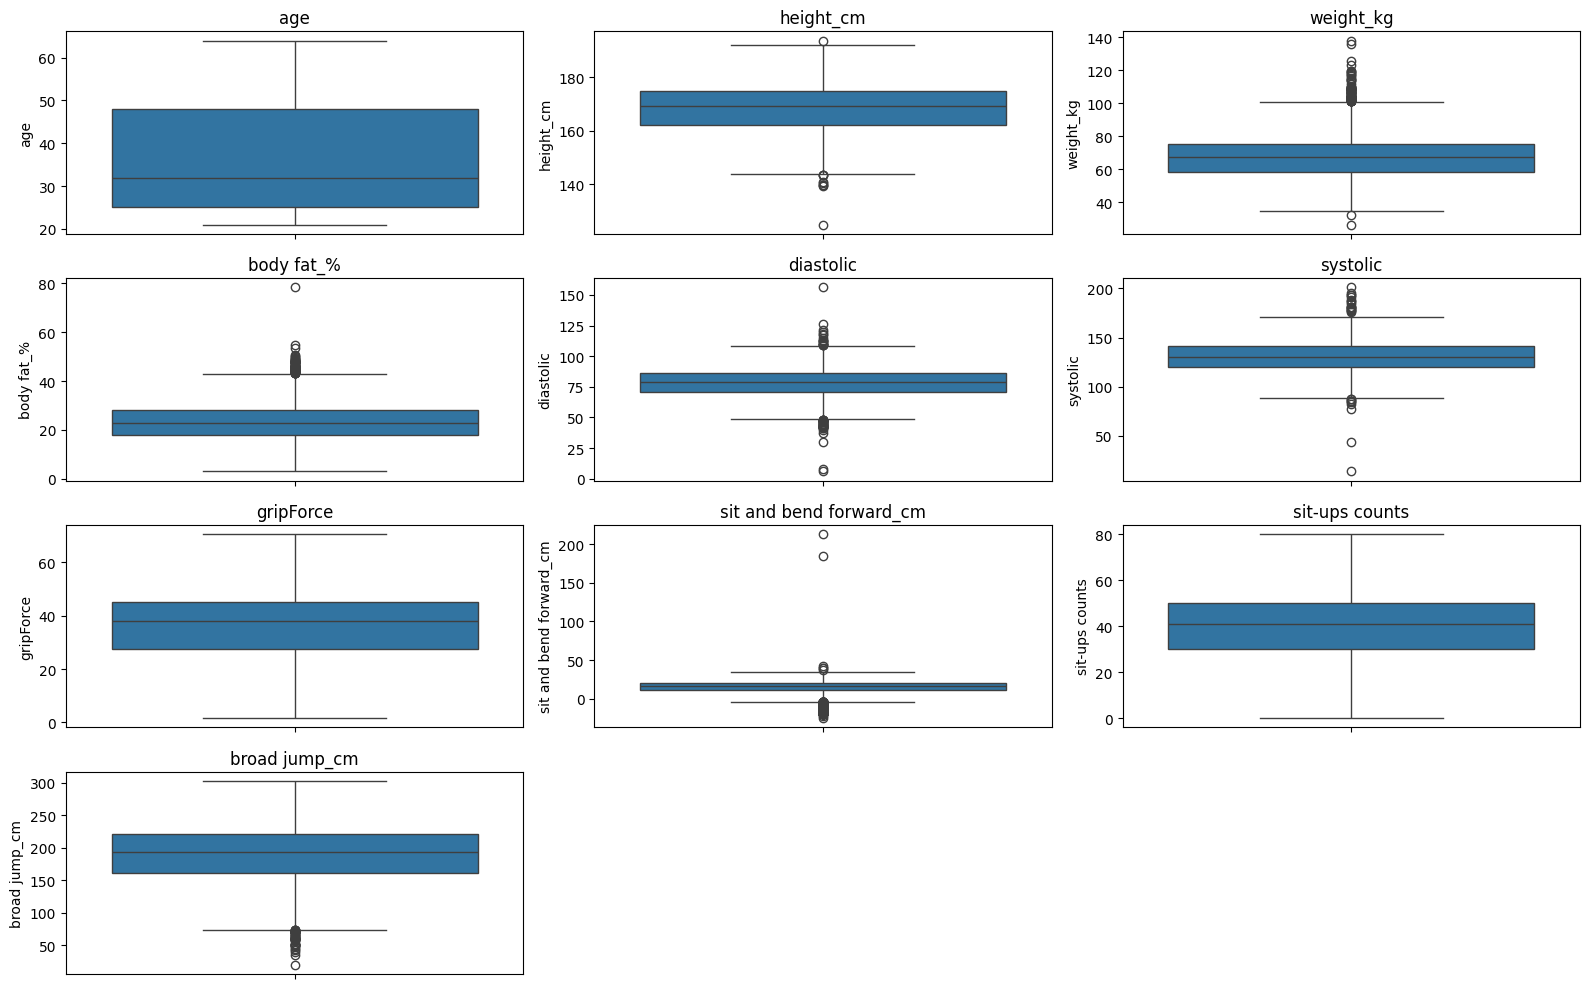

In [18]:

plt.figure(figsize=(16, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=df_clean_basic[col])
    plt.title(col)
plt.tight_layout()
plt.show()

Most of the extreme values look like natural variation — athletes exist, so high performance numbers aren't suspicious by themselves. But a handful of observations are so far outside the distribution that they're hard to explain as real measurements. We'll remove those specific ones and leave the rest alone.


In [19]:
# Remove only the highly suspicious extreme rows
suspicious_mask = (
    (df_clean_basic['body fat_%'] > 60) |
    (df_clean_basic['sit and bend forward_cm'] > 100)
)

suspicious_rows = df_clean_basic.loc[suspicious_mask].copy()
display(suspicious_rows)

df_clean_final = df_clean_basic.loc[~suspicious_mask].copy()
df_clean_final.reset_index(drop=True, inplace=True)

print("Shape before removing suspicious extremes:", df_clean_basic.shape)
print("Number of suspicious extreme rows removed:", suspicious_rows.shape[0])
print("Final cleaned shape:", df_clean_final.shape)

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
733,21.00,M,177.60,74.50,78.40,69.00,122.00,44.90,26.10,59.00,235.00,A
2654,33.00,M,165.60,60.40,17.80,81.00,127.00,38.60,213.00,53.00,244.00,B
3352,45.00,M,164.40,64.40,24.30,96.00,142.00,38.50,185.00,44.00,223.00,A


Shape before removing suspicious extremes: (13378, 12)
Number of suspicious extreme rows removed: 3
Final cleaned shape: (13375, 12)


## Outlier decision

These records were removed because they contained highly suspicious extreme values, such as unusually high body fat percentages or flexibility measurements far beyond the normal range of the dataset. They were treated as likely data quality problems rather than meaningful observations.

## Correlation analysis

The correlation matrix is used to examine the strength and direction of linear relationships between numeric variables, especially with `broad jump_cm`, which is the regression target.

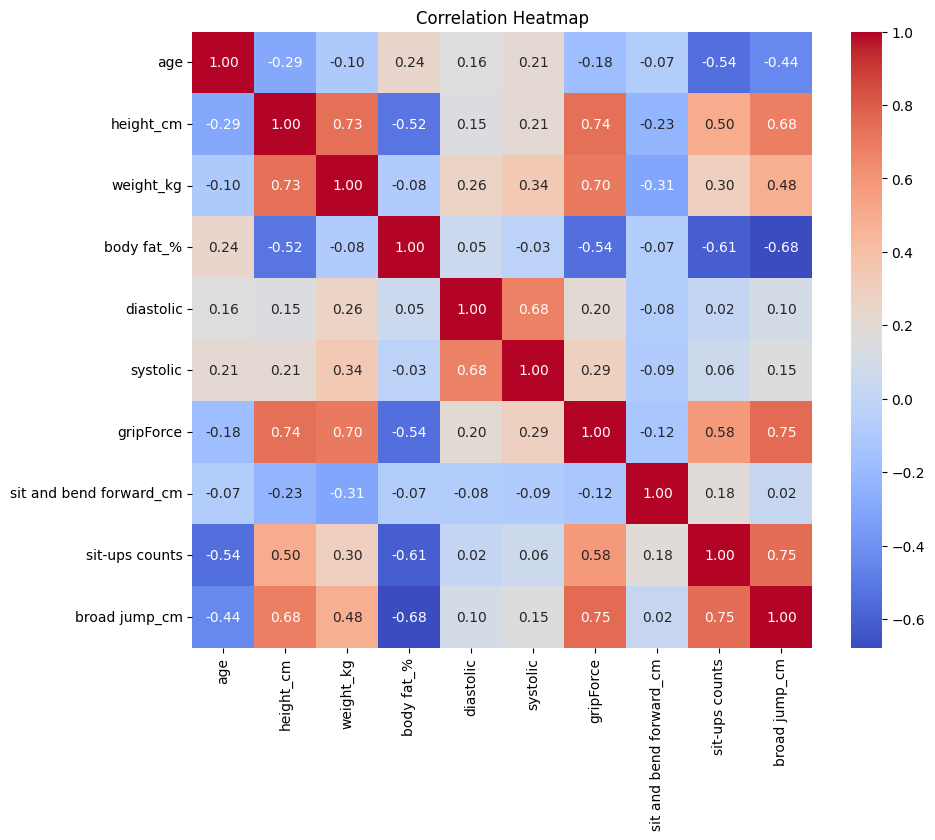

In [20]:
# Final numeric columns
numeric_cols = df_clean_final.select_dtypes(include='number').columns.tolist()

# Correlation matrix
corr_matrix = df_clean_final[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

The strongest positive correlations with `broad jump_cm` appear in grip strength, sit-up count, and height, while age and body fat percentage show negative relationships. These patterns are consistent with the expected physical meaning of the variables.

## Bivariate analysis

Scatter plots are used to visualize the relationships between `broad jump_cm` and the most relevant predictors identified in the correlation analysis.

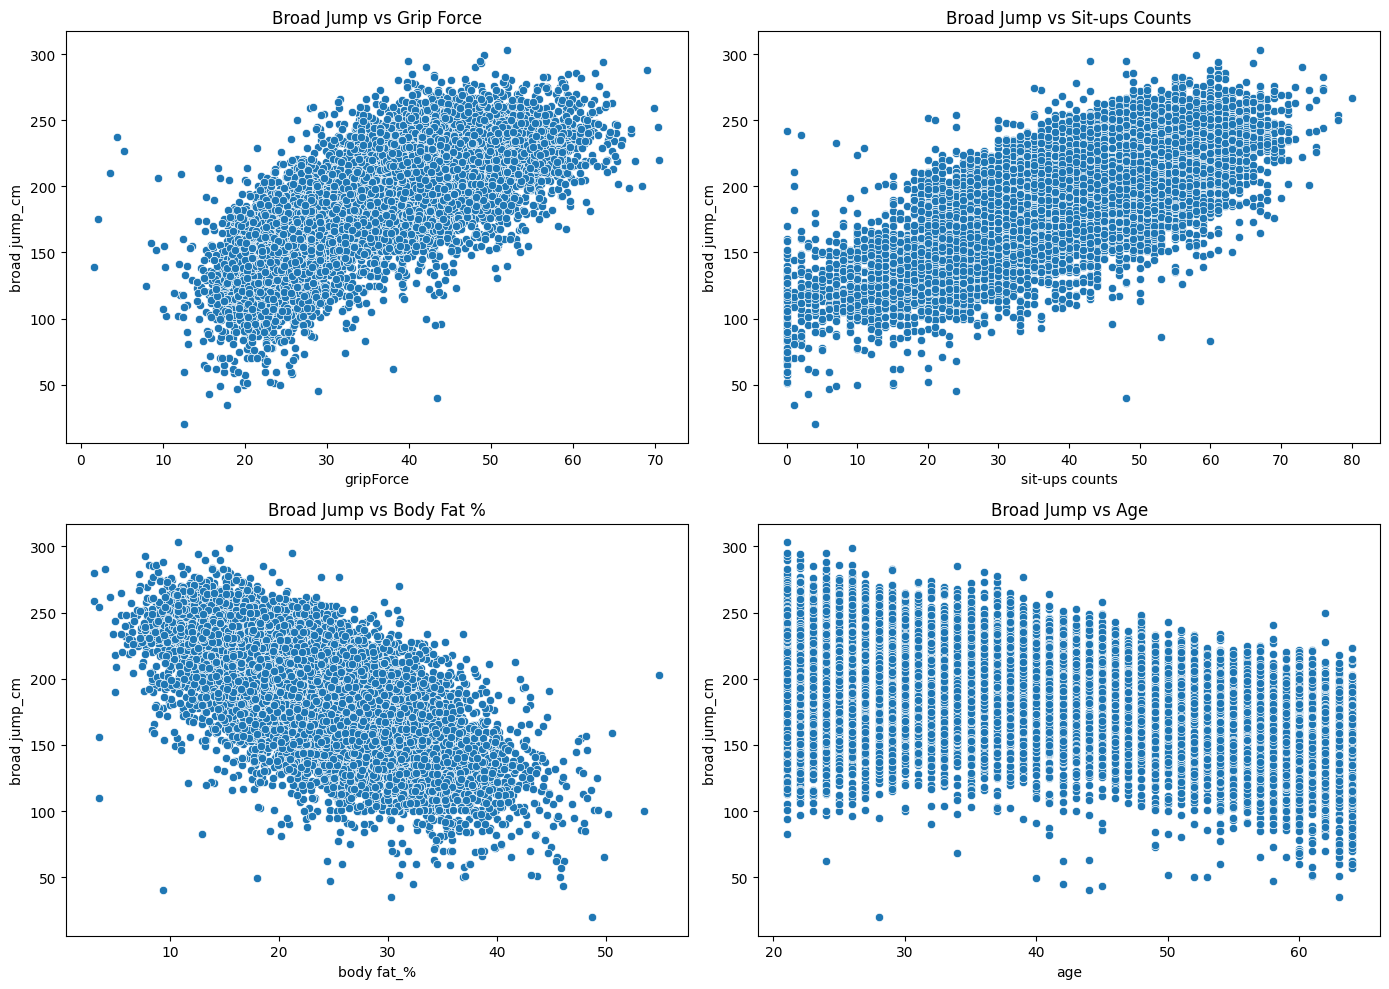

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.scatterplot(data=df_clean_final, x='gripForce', y='broad jump_cm', ax=axes[0, 0])
axes[0, 0].set_title('Broad Jump vs Grip Force')

sns.scatterplot(data=df_clean_final, x='sit-ups counts', y='broad jump_cm', ax=axes[0, 1])
axes[0, 1].set_title('Broad Jump vs Sit-ups Counts')

sns.scatterplot(data=df_clean_final, x='body fat_%', y='broad jump_cm', ax=axes[1, 0])
axes[1, 0].set_title('Broad Jump vs Body Fat %')

sns.scatterplot(data=df_clean_final, x='age', y='broad jump_cm', ax=axes[1, 1])
axes[1, 1].set_title('Broad Jump vs Age')

plt.tight_layout()
plt.show()

The scatter plots confirm what the correlation matrix suggested. Jump distance rises with grip strength and sit-up count, and falls as body fat and age increase. The relationships are real but noisy — plenty of scatter around each trend, which is normal for human performance data.


## Broad jump by performance class


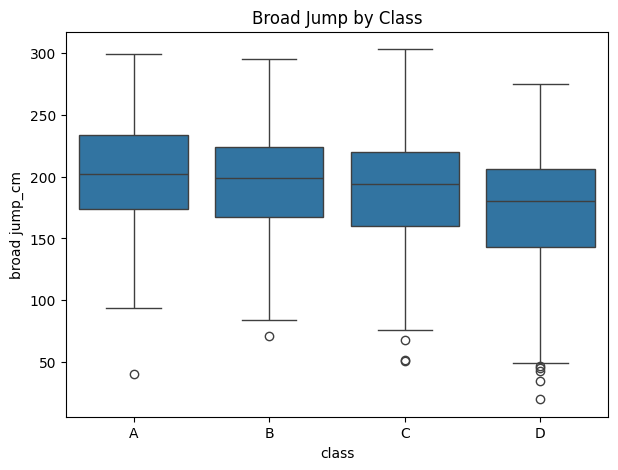

In [22]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df_clean_final, x='class', y='broad jump_cm', order=['A', 'B', 'C', 'D'])
plt.title('Broad Jump by Class')
plt.show()

The class-wise boxplot shows noticeable overlap between the middle classes, especially `B` and `C`.

This is an important observation because it suggests that classification may be naturally difficult, even with reasonable preprocessing and modeling.

## Grip strength by gender


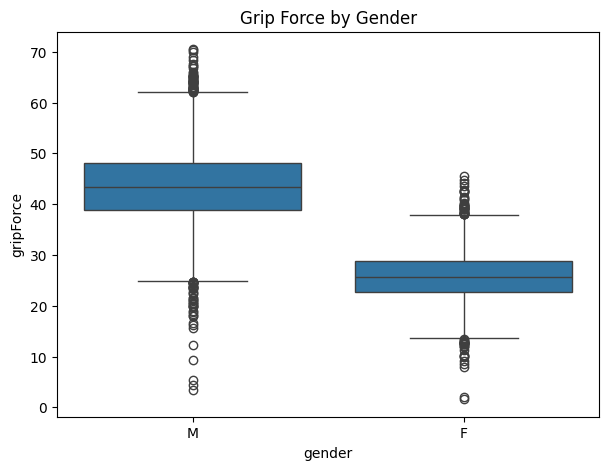

In [23]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df_clean_final, x='gender', y='gripForce')
plt.title('Grip Force by Gender')
plt.show()

Grip strength splits cleanly by gender — this is exactly what was producing the bimodal shape in the histogram. Male and female participants have distinct grip strength distributions with limited overlap. Gender is going to be a meaningful input for the models.


## Summary of data quality issues

We found five things worth noting during the cleaning process:

1. One exact duplicate row — removed.
2. A small number of physically impossible measurements — removed.
3. A few highly suspicious extreme values (body fat > 60%, flexibility > 100 cm) — removed.
4. More male than female participants — noted as a potential confound.
5. Visible overlap between the middle performance classes (B and C) — likely to make classification harder.

Everything else we left alone.


## EDA summary — what we learned

The dataset is cleaner than most. No missing values, only one duplicate, and the invalid records we removed represent less than 1% of the total.

The main findings that will shape the modeling:

- The target classes are nearly balanced, so classification metrics won't be misleading.
- Grip strength, sit-up count, and height are the strongest predictors of jump distance.
- Body fat and age work against performance.
- Gender creates a systematic split in several physical variables — it belongs in the model.
- Classes B and C overlap more than A and D. The classification task won't be easy.

These observations drove every decision in the feature engineering and model selection steps that follow.


## Preprocessing plan

Based on what we found in the EDA:

- Keep the cleaned dataset (invalid and extreme records already removed).
- Encode `gender` — the only categorical input feature.
- Scale numeric features — several models we're testing are sensitive to feature magnitude.
- Use `class` as the classification target, `broad jump_cm` as the regression target.
- Test engineered features against the originals to see if they actually help.


## Feature Engineering

To examine whether transformed variables can improve performance, several engineered features were created from the original measurements. These features were designed to capture body composition, blood pressure structure, relative strength, and exercise performance adjusted for age.


The engineered variables include BMI, pulse pressure, mean arterial pressure, grip-to-weight ratio, lean mass approximation, fat mass, and sit-ups adjusted for age.

### BMI

In [24]:
df_fe = df_clean_final.copy()

df_fe['BMI'] = df_fe['weight_kg'] / (df_fe['height_cm'] / 100) ** 2

df_fe['pulse_pressure'] = df_fe['systolic'] - df_fe['diastolic']

df_fe['MAP'] = (2 * df_fe['diastolic'] + df_fe['systolic']) / 3

df_fe['grip_to_weight'] = df_fe['gripForce'] / df_fe['weight_kg']

df_fe['lean_mass_kg'] = df_fe['weight_kg'] * (1 - df_fe['body fat_%'] / 100)

df_fe['fat_mass_kg'] = df_fe['weight_kg'] * (df_fe['body fat_%'] / 100)

df_fe['situps_age_ratio'] = df_fe['sit-ups counts'] / df_fe['age']

Not all engineered features were equally useful. In later comparisons, lean mass, grip-to-weight ratio, and sit-ups adjusted for age appeared more promising than the rest.


In [25]:
engineered_cols = [
    'BMI', 'pulse_pressure', 'MAP',
    'grip_to_weight', 'lean_mass_kg',
    'fat_mass_kg', 'situps_age_ratio'
]

corr_with_target = df_fe[engineered_cols + ['broad jump_cm']].corr()['broad jump_cm'].sort_values(ascending=False)
display(corr_with_target)

,broad jump_cm
broad jump_cm,1.00
lean_mass_kg,0.73
grip_to_weight,0.66
situps_age_ratio,0.63
BMI,0.15
MAP,0.13
pulse_pressure,0.11
fat_mass_kg,-0.34


The correlation check on engineered features is encouraging. `lean_mass_kg`, `grip_to_weight`, and `situps_age_ratio` all show meaningful relationships with broad jump distance. These three will be the ones we carry forward into the model comparison.


## Preparing the modeling datasets

We now set up the input/output pairs for both tasks. Classification and regression get separate feature sets so we can evaluate them independently and without one leaking information into the other.


## Train-test split

We hold out 20% of the data for final evaluation. For classification, we use stratified splitting to make sure each class is proportionally represented in both the training and test sets — otherwise the class distribution in the test set could differ from training and skew the results.


In [26]:
original_features = [
    'age', 'gender', 'height_cm', 'weight_kg', 'body fat_%',
    'diastolic', 'systolic', 'gripForce',
    'sit and bend forward_cm', 'sit-ups counts'
]

In [27]:
# Regression target
y_reg = df_fe['broad jump_cm']

# 1) Original features only
X_reg_base = df_fe[original_features].copy()

# 2) Original + strongest engineered features
X_reg_strong = df_fe[original_features + ['lean_mass_kg', 'grip_to_weight', 'situps_age_ratio']].copy()

# 3) Original + strongest + optional feature
X_reg_extended = df_fe[original_features + ['lean_mass_kg', 'grip_to_weight', 'situps_age_ratio', 'fat_mass_kg']].copy()

### Same structure for classification


In [28]:
# Classification target
y_clf = df_fe['class']

# 1) Original features only
X_clf_base = df_fe[original_features + ['broad jump_cm']].copy()

# 2) Original + strongest engineered features
X_clf_strong = df_fe[original_features + ['broad jump_cm', 'lean_mass_kg', 'grip_to_weight', 'situps_age_ratio']].copy()

# 3) Original + strongest + optional
X_clf_extended = df_fe[original_features + ['broad jump_cm', 'lean_mass_kg', 'grip_to_weight', 'situps_age_ratio', 'fat_mass_kg']].copy()

In [29]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Classification models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

# Classification metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Regression metrics
from sklearn.metrics import mean_squared_error, r2_score

## Helper: preprocessor builder

Detects numeric and categorical columns automatically and returns a fitted `ColumnTransformer`. Called before every pipeline so each experiment uses the correct feature set.


In [30]:
def build_preprocessor(X):
    numeric_features = X.select_dtypes(include=['number']).columns.tolist()
    categorical_features = X.select_dtypes(include=['object']).columns.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_features),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
        ]
    )

    return preprocessor, numeric_features, categorical_features

## Baseline models

Baseline models are evaluated first to provide a reference point for later comparisons. Their results show how much improvement is gained from feature engineering and final model selection.

## Baseline classification results

We report Accuracy, Macro Precision, Macro Recall, and Macro F1. Macro averaging treats all four classes equally, which is appropriate here since the classes are balanced. Accuracy alone would have been fine given the balance, but the additional metrics help catch any model that's quietly struggling on one specific class.


## Baseline regression results

RMSE measures average prediction error in the same units as the target (centimeters of jump distance). R² tells us what fraction of the variance the model is capturing. Both together give a clearer picture than either alone.


### Train-test split — classification (stratified 80/20)


In [31]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf_base, y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

### Train-test split — regression (80/20)


In [32]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg_base, y_reg,
    test_size=0.2,
    random_state=42
)

In [33]:
clf_models = {
    'KNN Classifier': KNeighborsClassifier(),
    'Decision Tree Classifier': DecisionTreeClassifier(random_state=42),
    'SVM Classifier': SVC(),
    'MLP Classifier': MLPClassifier(hidden_layer_sizes=(64,), max_iter=1000, random_state=42)
}

### Regression model definitions


In [34]:
reg_models = {
    'Linear Regression': LinearRegression(),
    'KNN Regressor': KNeighborsRegressor(),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'SVR': SVR(),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(64,), max_iter=1000, random_state=42)
}

## Classification evaluation function


In [35]:
def evaluate_classification_models(X_train, X_test, y_train, y_test, X_reference, models):
    results = []

    preprocessor, numeric_features, categorical_features = build_preprocessor(X_reference)

    for model_name, model in models.items():
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ])

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        results.append({
            'Model': model_name,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision_macro': precision_score(y_test, y_pred, average='macro', zero_division=0),
            'Recall_macro': recall_score(y_test, y_pred, average='macro', zero_division=0),
            'F1_macro': f1_score(y_test, y_pred, average='macro', zero_division=0)
        })

    return pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)

## Regression evaluation function


In [36]:
def evaluate_regression_models(X_train, X_test, y_train, y_test, X_reference, models):
    results = []

    preprocessor, numeric_features, categorical_features = build_preprocessor(X_reference)

    for model_name, model in models.items():
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ])

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        results.append({
            'Model': model_name,
            'RMSE': rmse,
            'R2': r2_score(y_test, y_pred)
        })

    return pd.DataFrame(results).sort_values(by='R2', ascending=False)

### Running the baselines


In [37]:
clf_results_base = evaluate_classification_models(
    X_train_clf, X_test_clf, y_train_clf, y_test_clf,
    X_clf_base, clf_models
)

display(clf_results_base)

,Model,Accuracy,Precision_macro,Recall_macro,F1_macro
3,MLP Classifier,0.75,0.75,0.75,0.74
2,SVM Classifier,0.69,0.70,0.69,0.69
1,Decision Tree Classifier,0.64,0.64,0.64,0.64
0,KNN Classifier,0.59,0.61,0.59,0.59


In [38]:
reg_results_base = evaluate_regression_models(
    X_train_reg, X_test_reg, y_train_reg, y_test_reg,
    X_reg_base, reg_models
)

display(reg_results_base)

,Model,RMSE,R2
4,MLP Regressor,18.01,0.80
0,Linear Regression,18.36,0.79
3,SVR,19.02,0.77
1,KNN Regressor,19.45,0.76
2,Decision Tree Regressor,25.48,0.59


## Evaluation Across Different Train-Test Splits

To check whether the selected classification model remains stable under different train-test proportions, it is evaluated using three standard split settings: 80:20, 70:30, and 50:50.


### Classification — with engineered features


In [39]:
X_train_clf_s, X_test_clf_s, y_train_clf_s, y_test_clf_s = train_test_split(
    X_clf_strong, y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

clf_results_strong = evaluate_classification_models(
    X_train_clf_s, X_test_clf_s, y_train_clf_s, y_test_clf_s,
    X_clf_strong, clf_models
)

display(clf_results_strong)

,Model,Accuracy,Precision_macro,Recall_macro,F1_macro
3,MLP Classifier,0.75,0.76,0.75,0.75
2,SVM Classifier,0.68,0.69,0.68,0.68
1,Decision Tree Classifier,0.64,0.64,0.64,0.64
0,KNN Classifier,0.58,0.60,0.58,0.58


### Regression — with engineered features


In [40]:
X_train_reg_s, X_test_reg_s, y_train_reg_s, y_test_reg_s = train_test_split(
    X_reg_strong, y_reg,
    test_size=0.2,
    random_state=42
)

reg_results_strong = evaluate_regression_models(
    X_train_reg_s, X_test_reg_s, y_train_reg_s, y_test_reg_s,
    X_reg_strong, reg_models
)

display(reg_results_strong)

,Model,RMSE,R2
4,MLP Regressor,18.04,0.80
0,Linear Regression,18.26,0.79
3,SVR,19.04,0.77
1,KNN Regressor,19.38,0.77
2,Decision Tree Regressor,25.25,0.60


### Side-by-side comparison: base vs. engineered


In [41]:
def compare_two_results(base_df, strong_df, metric_col):
    comparison = pd.DataFrame({
        'Base': base_df.set_index('Model')[metric_col],
        'Strong_FE': strong_df.set_index('Model')[metric_col]
    })
    comparison['Difference'] = comparison['Strong_FE'] - comparison['Base']
    return comparison.sort_values(by='Difference', ascending=False)

#### Classification comparison


In [42]:
display(compare_two_results(clf_results_base, clf_results_strong, 'Accuracy'))

,Base,Strong_FE,Difference
Model,,,
MLP Classifier,0.75,0.75,0.01
Decision Tree Classifier,0.64,0.64,0.00
SVM Classifier,0.69,0.68,-0.01
KNN Classifier,0.59,0.58,-0.01


#### Regression comparison


In [43]:
display(compare_two_results(reg_results_base, reg_results_strong, 'R2'))

,Base,Strong_FE,Difference
Model,,,
Decision Tree Regressor,0.59,0.60,0.01
Linear Regression,0.79,0.79,0.00
KNN Regressor,0.76,0.77,0.00
SVR,0.77,0.77,-0.00
MLP Regressor,0.80,0.80,-0.00


#### Model comparison charts

The following charts summarize model performance visually for both tasks. They make it easier to compare the relative performance of the tested algorithms.

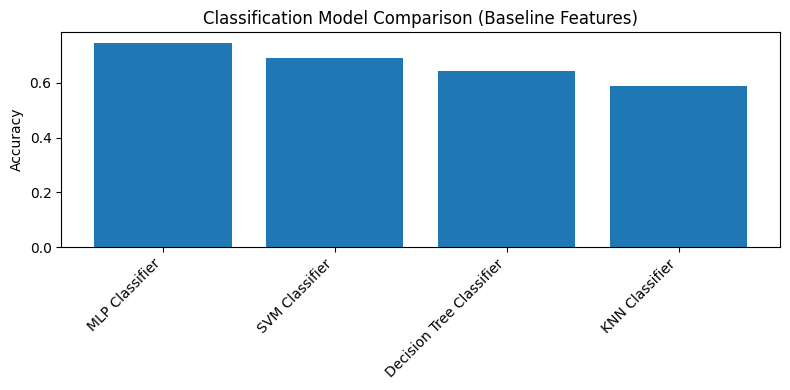

In [44]:
plt.figure(figsize=(8, 4))
plt.bar(clf_results_base['Model'], clf_results_base['Accuracy'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Accuracy')
plt.title('Classification Model Comparison (Baseline Features)')
plt.tight_layout()
plt.show()

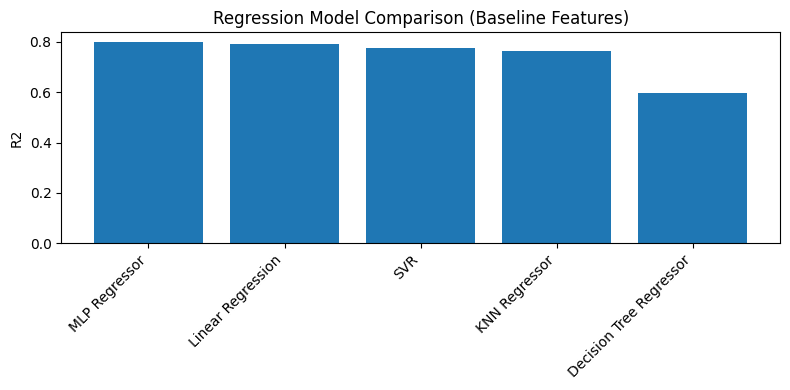

In [45]:
plt.figure(figsize=(8, 4))
plt.bar(reg_results_base['Model'], reg_results_base['R2'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('R2')
plt.title('Regression Model Comparison (Baseline Features)')
plt.tight_layout()
plt.show()

The comparison charts show that model performance differs across algorithms, but the strongest models remain clearly identifiable in both tasks. These charts support the final choice of the classification and regression models used later in the notebook.

The comparison between original and engineered features shows a limited but meaningful effect. In classification, the improvement is modest and appears more clearly for some models than others. In regression, the strongest models remain close to their previous performance, with only small gains from the engineered features.

Overall, the original features already contain most of the predictive information, while engineered features provide only minor additional benefit.

In [46]:
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Final selected datasets
X_clf_final = X_clf_strong
y_clf_final = y_clf

X_reg_final = X_reg_base
y_reg_final = y_reg

# Final selected models
final_clf_model = MLPClassifier(hidden_layer_sizes=(64,), max_iter=500, random_state=42)
final_reg_model = LinearRegression()

### Split sensitivity — classification


In [47]:
def evaluate_classification_split(X, y, test_size, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    pipeline = Pipeline([
        ('preprocessor', build_preprocessor(X)[0]),
        ('model', final_clf_model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    return {
        'Split': f"{int((1-test_size)*100)}:{int(test_size*100)}",
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision_macro': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'Recall_macro': recall_score(y_test, y_pred, average='macro', zero_division=0),
        'F1_macro': f1_score(y_test, y_pred, average='macro', zero_division=0)
    }

### Split sensitivity — regression


In [48]:
def evaluate_regression_split(X, y, test_size, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state
    )

    pipeline = Pipeline([
        ('preprocessor', build_preprocessor(X)[0]),
        ('model', final_reg_model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    return {
        'Split': f"{int((1-test_size)*100)}:{int(test_size*100)}",
        'RMSE': rmse,
        'R2': r2_score(y_test, y_pred)
    }

### Running split sensitivity — classification


In [49]:
clf_split_results = pd.DataFrame([
    evaluate_classification_split(X_clf_final, y_clf_final, 0.20),
    evaluate_classification_split(X_clf_final, y_clf_final, 0.30),
    evaluate_classification_split(X_clf_final, y_clf_final, 0.50)
])

display(clf_split_results)

,Split,Accuracy,Precision_macro,Recall_macro,F1_macro
0,80:20,0.75,0.76,0.75,0.75
1,70:30,0.75,0.75,0.75,0.75
2,50:50,0.74,0.74,0.74,0.74


### Running split sensitivity — regression


In [50]:
reg_split_results = pd.DataFrame([
    evaluate_regression_split(X_reg_final, y_reg_final, 0.20),
    evaluate_regression_split(X_reg_final, y_reg_final, 0.30),
    evaluate_regression_split(X_reg_final, y_reg_final, 0.50)
])

display(reg_split_results)

,Split,RMSE,R2
0,80:20,18.36,0.79
1,70:30,18.11,0.79
2,50:50,17.87,0.79


## K-Fold Cross Validation

Single train-test splits may vary slightly depending on how the data is divided. For this reason, 5-fold cross validation is used to obtain a more stable estimate of classification performance.


### 5-fold CV — classification


In [51]:
clf_pipeline_cv = Pipeline([
    ('preprocessor', build_preprocessor(X_clf_final)[0]),
    ('model', final_clf_model)
])

clf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

clf_cv_scores = cross_val_score(
    clf_pipeline_cv,
    X_clf_final,
    y_clf_final,
    cv=clf_cv,
    scoring='accuracy',
    n_jobs=-1
)

print("Classification 5-Fold Accuracy Scores:", clf_cv_scores)
print("Mean CV Accuracy:", clf_cv_scores.mean())
print("Std CV Accuracy:", clf_cv_scores.std())

Classification 5-Fold Accuracy Scores: [0.74841121 0.74018692 0.72635514 0.74542056 0.74915888]
Mean CV Accuracy: 0.7419065420560749
Std CV Accuracy: 0.00839117030076899


### 5-fold CV — regression


In [52]:
reg_pipeline_cv = Pipeline([
    ('preprocessor', build_preprocessor(X_reg_final)[0]),
    ('model', final_reg_model)
])

reg_cv = KFold(n_splits=5, shuffle=True, random_state=42)

reg_cv_scores = cross_val_score(
    reg_pipeline_cv,
    X_reg_final,
    y_reg_final,
    cv=reg_cv,
    scoring='r2',
    n_jobs=-1
)

print("Regression 5-Fold R2 Scores:", reg_cv_scores)
print("Mean CV R2:", reg_cv_scores.mean())
print("Std CV R2:", reg_cv_scores.std())

Regression 5-Fold R2 Scores: [0.78955303 0.79744818 0.7953136  0.79018862 0.78926254]
Mean CV R2: 0.7923531951611217
Std CV R2: 0.003370500818946521


## Confusion Matrix for the Final Classification Model

The confusion matrix is shown for the 80:20 split in order to examine class-level prediction behavior in a fixed test set. This helps identify which performance categories are most frequently confused.

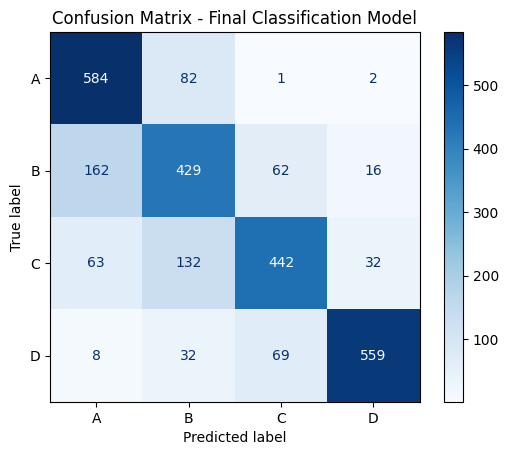

In [53]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf_final, y_clf_final,
    test_size=0.2,
    random_state=42,
    stratify=y_clf_final
)

clf_pipeline_final = Pipeline([
    ('preprocessor', build_preprocessor(X_clf_final)[0]),
    ('model', final_clf_model)
])

clf_pipeline_final.fit(X_train_clf, y_train_clf)
y_pred_clf = clf_pipeline_final.predict(X_test_clf)

cm = confusion_matrix(y_test_clf, y_pred_clf, labels=['A', 'B', 'C', 'D'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['A', 'B', 'C', 'D'])

disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Final Classification Model')
plt.show()

The confusion matrix shows that the model predicts the outer classes more clearly than the middle classes. Most of the confusion appears between adjacent performance levels, especially B and C, which suggests overlap between these categories in the original measurements.

## Actual vs. predicted — regression final model


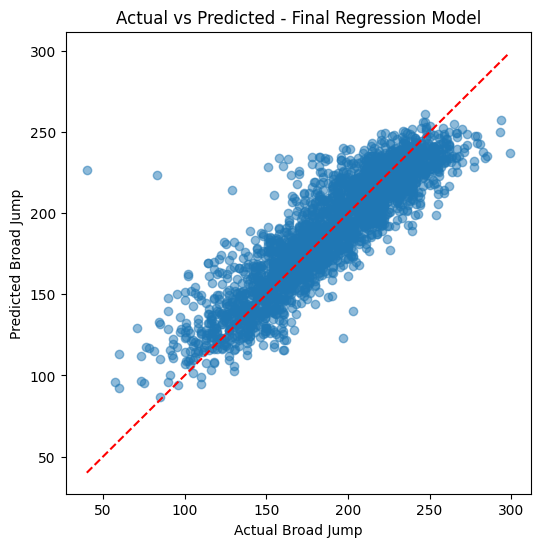

In [54]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg_final, y_reg_final,
    test_size=0.2,
    random_state=42
)

reg_pipeline_final = Pipeline([
    ('preprocessor', build_preprocessor(X_reg_final)[0]),
    ('model', final_reg_model)
])

reg_pipeline_final.fit(X_train_reg, y_train_reg)
y_pred_reg = reg_pipeline_final.predict(X_test_reg)

plt.figure(figsize=(6,6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.5)
plt.xlabel('Actual Broad Jump')
plt.ylabel('Predicted Broad Jump')
plt.title('Actual vs Predicted - Final Regression Model')
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'r--')
plt.show()

Most predicted values follow the general direction of the actual values, with reasonable concentration around the diagonal reference line. Some spread remains, especially near the extreme values, but the overall pattern indicates that the regression model captures the main relationship in the data effectively.

## Final Conclusion

This notebook presented a complete workflow for analyzing the Body Performance dataset through both classification and regression tasks.

The data preparation stage showed that the dataset was mostly clean, with no missing values and only a small number of invalid or highly suspicious records that needed to be removed. The exploratory analysis also revealed several meaningful relationships between performance and variables such as grip strength, sit-up count, body fat percentage, height, and age.

For classification, the selected final model produced stable performance across the different train-test splits, with accuracy remaining around 74–75%. The 5-fold cross-validation results were also consistent, with mean accuracy close to 74%. The confusion matrix showed that the model handled the outer classes better than the middle ones, which suggests that overlap between classes such as B and C makes the task naturally difficult.

For regression, the final Linear Regression model performed more strongly and more consistently. Across the different train-test splits, the R² score remained close to 0.79, while RMSE stayed around 18 cm. The 5-fold cross-validation results were also very stable, which increases confidence in the regression model.

Overall, the dataset supports meaningful prediction in both tasks, but the regression problem appears easier and more stable than the classification problem. The classification task remains limited mainly by overlap between some performance categories rather than by a lack of useful predictors.